
# Lab-7

**Name:** Abdul Qudoos 
**CMS:** 023-24-0233  
**Section:** G  
**GitHub Profile:**(https://github.com/abdulqudoos181005)
**Kaggle Profile:** https://www.kaggle.com/abdulqudoos7860 
 

## task-A:

### 1.

In [5]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


## TASK 1: Load Both Datasets

In [6]:
# Load datasets
spam_df = pd.read_csv("spam.csv", encoding='latin-1')
tweets_df = pd.read_csv("Tweets.csv", encoding='latin-1')

# -----------------------------
# Spam Dataset
# -----------------------------

print("SPAM DATASET")
print("Shape:", spam_df.shape)

print("\nFirst 5 rows:")
display(spam_df.head())
# Keep only the two useful columns from SMS dataset

spam_df = spam_df.iloc[:, :2]
spam_df.columns = ["label", "message"]

print(spam_df.head())
print(spam_df.columns)


spam_counts = spam_df["label"].value_counts()
spam_percent = spam_df["label"].value_counts(normalize=True) * 100

spam_balance = pd.DataFrame({
    "Count": spam_counts,
    "Percentage": spam_percent.round(2)
})

print(spam_balance)

# Keep only positive and negative tweets

tweets_df = tweets_df[
    tweets_df["airline_sentiment"].isin(["positive", "negative"])
].copy()

print("Twitter dataset after removing neutral tweets:")
print(tweets_df.shape)

print("\nClass balance:")
print(tweets_df["airline_sentiment"].value_counts())

print("\nClass percentages:")
print(
    tweets_df["airline_sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


SPAM DATASET
Shape: (5572, 5)

First 5 rows:


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Index(['label', 'message'], dtype='str')
       Count  Percentage
label                   
ham     4825       86.59
spam     747       13.41
Twitter dataset after removing neutral tweets:
(11541, 15)

Class balance:
airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64

Class percentages:
airline_sentiment
negative    79.53
positive    20.47
Name: proportion, dtype: float64


### Task 1 Interpretation

The SMS dataset contains one row per SMS message and uses `ham` and `spam` as the two classes. The Twitter dataset contains one row per tweet and has three sentiment classes: negative, neutral, and positive.

## TASK 2: Practical Problem

### SMS Spam

The goal is to automatically identify whether an SMS message is legitimate or spam. It is a binary classification problem because each message belongs to either `ham` or `spam`.

### Twitter Sentiment

The goal is to classify airline-related tweets according to sentiment. For this lab, only `positive` and `negative` tweets are used, making it a binary classification problem.

## TASK 3: Lightly Clean SMS Text

In [7]:
def clean_sms(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

spam_df["clean_message"] = spam_df["message"].apply(clean_sms)

display(spam_df[["message", "clean_message"]].head())

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## TASK 4: Encode Labels, Split Data & Vectorize

In [8]:
# Encode labels: ham = 0, spam = 1
spam_df["label_num"] = spam_df["label"].map({
    "ham": 0,
    "spam": 1
})

X_spam = spam_df["clean_message"]
y_spam = spam_df["label_num"]

# Train/test split
X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X_spam,
    y_spam,
    test_size=0.20,
    random_state=42,
    stratify=y_spam
)

# Fit vectorizer ONLY on training data
spam_vectorizer = CountVectorizer()
X_train_spam_vec = spam_vectorizer.fit_transform(X_train_spam)
X_test_spam_vec = spam_vectorizer.transform(X_test_spam)

print("Training samples:", len(X_train_spam))
print("Testing samples:", len(X_test_spam))
print("Training feature matrix:", X_train_spam_vec.shape)
print("Testing feature matrix:", X_test_spam_vec.shape)
print("Vocabulary size:", len(spam_vectorizer.vocabulary_))

Training samples: 4457
Testing samples: 1115
Training feature matrix: (4457, 8343)
Testing feature matrix: (1115, 8343)
Vocabulary size: 8343


### Why fit only on training data?

The vectorizer learns its vocabulary from the training set. The test set is only transformed using that already-learned vocabulary. This prevents information from the test set leaking into the training process.

## TASK 5: Train Multinomial Naive Bayes

In [9]:
spam_nb = MultinomialNB()
spam_nb.fit(X_train_spam_vec, y_train_spam)

spam_pred = spam_nb.predict(X_test_spam_vec)

spam_accuracy = accuracy_score(y_test_spam, spam_pred)
spam_precision = precision_score(y_test_spam, spam_pred)
spam_recall = recall_score(y_test_spam, spam_pred)
spam_f1 = f1_score(y_test_spam, spam_pred)

print(f"Accuracy : {spam_accuracy:.4f}")
print(f"Precision: {spam_precision:.4f}")
print(f"Recall   : {spam_recall:.4f}")
print(f"F1 Score : {spam_f1:.4f}")

Accuracy : 0.9758
Precision: 0.9552
Recall   : 0.8591
F1 Score : 0.9046


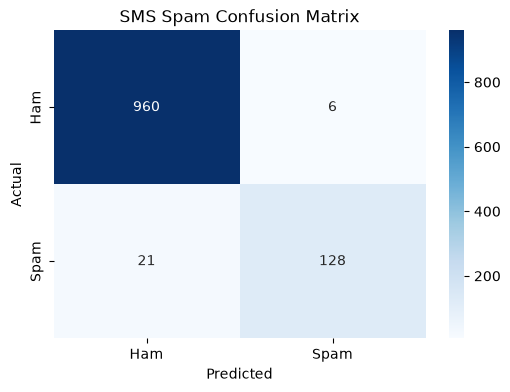

Confusion matrix interpretation:
Rows = actual classes, columns = predicted classes.


In [10]:
cm_spam = confusion_matrix(y_test_spam, spam_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_spam,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SMS Spam Confusion Matrix")
plt.show()

print("Confusion matrix interpretation:")
print("Rows = actual classes, columns = predicted classes.")

## TASK 6: False Positive vs False Negative

**False Positive:** A legitimate ham message is incorrectly classified as spam.

**False Negative:** An actual spam message is incorrectly classified as ham.

Both errors matter. Precision is important when we want to avoid incorrectly marking legitimate messages as spam, while recall is important when we want to catch as much actual spam as possible.

## TASK 7: Find 15 Words Associated With Spam and 15 With Ham

In [11]:
feature_names = np.array(spam_vectorizer.get_feature_names_out())

# feature_log_prob_[0] = ham
# feature_log_prob_[1] = spam
log_probability_difference = (
    spam_nb.feature_log_prob_[1] - spam_nb.feature_log_prob_[0]
)

spam_indices = np.argsort(log_probability_difference)[-15:][::-1]
ham_indices = np.argsort(log_probability_difference)[:15]

spam_words = pd.DataFrame({
    "word": feature_names[spam_indices],
    "score": log_probability_difference[spam_indices]
})

ham_words = pd.DataFrame({
    "word": feature_names[ham_indices],
    "score": log_probability_difference[ham_indices]
})

print("15 words most associated with SPAM:")
display(spam_words)

print("15 words most associated with HAM:")
display(ham_words)

15 words most associated with SPAM:


,word,score
0,claim,5.532937
1,prize,5.183753
2,won,5.056598
3,500,4.616647
4,tone,4.616647
5,guaranteed,4.616647
6,18,4.534409
7,1000,4.505421
8,150,4.380258
9,tcs,4.346356


15 words most associated with HAM:


,word,score
0,ltgt,-4.437040
1,ill,-4.309207
2,he,-3.880752
3,lor,-3.872970
4,later,-3.774530
5,da,-3.765872
6,she,-3.595650
7,thats,-3.415389
8,my,-3.316523
9,doing,-3.255046


### Interpretation

A higher positive score means the word is more associated with spam than ham under the trained Naive Bayes model. A more negative score means the word is more associated with ham.

## TASK 8: Test Your Own Messages

In [12]:
test_messages = [
    "Congratulations! You have won a free prize. Claim your reward now!",
    "Hey, are you coming to university tomorrow?",
    "URGENT! You have won 1000 dollars. Call now to claim your reward."
]

clean_test_messages = [clean_sms(message) for message in test_messages]
test_vectors = spam_vectorizer.transform(clean_test_messages)
test_predictions = spam_nb.predict(test_vectors)

for message, prediction in zip(test_messages, test_predictions):
    label = "Spam" if prediction == 1 else "Ham"
    print("Message:", message)
    print("Prediction:", label)
    print("-" * 70)

Message: Congratulations! You have won a free prize. Claim your reward now!
Prediction: Spam
----------------------------------------------------------------------
Message: Hey, are you coming to university tomorrow?
Prediction: Ham
----------------------------------------------------------------------
Message: URGENT! You have won 1000 dollars. Call now to claim your reward.
Prediction: Spam
----------------------------------------------------------------------


## TASK 9: Kaggle Notebook for SMS Dataset

In [13]:
# Kaggle version of the Task A pipeline
# Change the input path if your Kaggle dataset folder has a different name.

# Example:
# kaggle_spam_path = "/kaggle/input/sms-spam-collection-dataset/spam.csv"

print("Use the same cleaning, splitting, vectorization, Naive Bayes, and evaluation pipeline above in the Kaggle notebook.")

Use the same cleaning, splitting, vectorization, Naive Bayes, and evaluation pipeline above in the Kaggle notebook.


## TASK 10: Kaggle Summary

This notebook applies Multinomial Naive Bayes to SMS spam detection. The messages are cleaned, converted into numerical features using CountVectorizer, and classified as ham or spam. Accuracy, precision, recall, F1-score, and a confusion matrix are used to evaluate the model.

## TASK 11: Load and Prepare Twitter Dataset

In [16]:
# Keep only positive and negative tweets
twitter_df_binary = tweets_df[
    tweets_df["airline_sentiment"].isin(["positive", "negative"])
].copy()

print("Rows after removing neutral tweets:", len(twitter_df_binary))
print("\nRemaining class counts:")
print(twitter_df_binary["airline_sentiment"].value_counts())

print("\nRemaining class percentages:")
print(
    (twitter_df_binary["airline_sentiment"].value_counts(normalize=True) * 100)
    .round(2)
)

Rows after removing neutral tweets: 11541

Remaining class counts:
airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64

Remaining class percentages:
airline_sentiment
negative    79.53
positive    20.47
Name: proportion, dtype: float64


## TASK 12: Clean Twitter Text

In [17]:
def clean_tweet(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove @mentions
    text = re.sub(r"@\w+", "", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-z0-9\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

twitter_df_binary["clean_text"] = twitter_df_binary["text"].apply(clean_tweet)

display(twitter_df_binary[["text", "clean_text"]].head())

,text,clean_text
1,@VirginAmerica plus you've added commercials t...,plus youve added commercials to the experience...
3,@VirginAmerica it's really aggressive to blast...,its really aggressive to blast obnoxious enter...
4,@VirginAmerica and it's a really big bad thing...,and its a really big bad thing about it
5,@VirginAmerica seriously would pay $30 a fligh...,seriously would pay 30 a flight for seats that...
6,"@VirginAmerica yes, nearly every time I fly VX...",yes nearly every time i fly vx this ear worm w...


### Why additional cleaning for tweets?

Tweets commonly contain usernames, links, punctuation, and other symbols. Removing these elements helps the model focus more on the textual content used for sentiment classification.

## TASK 13: Train Multinomial Naive Bayes on Tweets

In [18]:
# Encode labels: negative = 0, positive = 1
twitter_df_binary["sentiment_num"] = twitter_df_binary["airline_sentiment"].map({
    "negative": 0,
    "positive": 1
})

X_twitter = twitter_df_binary["clean_text"]
y_twitter = twitter_df_binary["sentiment_num"]

# Split
X_train_twitter, X_test_twitter, y_train_twitter, y_test_twitter = train_test_split(
    X_twitter,
    y_twitter,
    test_size=0.20,
    random_state=42,
    stratify=y_twitter
)

# Vectorize using training data only
twitter_vectorizer = CountVectorizer()

X_train_twitter_vec = twitter_vectorizer.fit_transform(X_train_twitter)
X_test_twitter_vec = twitter_vectorizer.transform(X_test_twitter)

print("Training feature matrix:", X_train_twitter_vec.shape)
print("Testing feature matrix:", X_test_twitter_vec.shape)
print("Vocabulary size:", len(twitter_vectorizer.vocabulary_))

# Train Naive Bayes
twitter_nb = MultinomialNB()
twitter_nb.fit(X_train_twitter_vec, y_train_twitter)

# Predict
twitter_pred = twitter_nb.predict(X_test_twitter_vec)

# Metrics
twitter_accuracy = accuracy_score(y_test_twitter, twitter_pred)
twitter_precision = precision_score(y_test_twitter, twitter_pred)
twitter_recall = recall_score(y_test_twitter, twitter_pred)
twitter_f1 = f1_score(y_test_twitter, twitter_pred)

print(f"\nAccuracy : {twitter_accuracy:.4f}")
print(f"Precision: {twitter_precision:.4f}")
print(f"Recall   : {twitter_recall:.4f}")
print(f"F1 Score : {twitter_f1:.4f}")

Training feature matrix: (9232, 11135)
Testing feature matrix: (2309, 11135)
Vocabulary size: 11135

Accuracy : 0.9030
Precision: 0.9308
Recall   : 0.5687
F1 Score : 0.7060


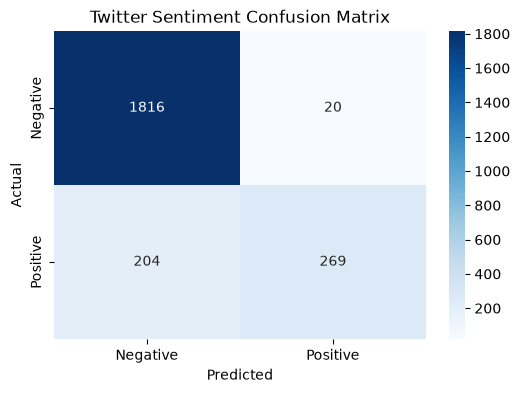

In [19]:
cm_twitter = confusion_matrix(y_test_twitter, twitter_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_twitter,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Twitter Sentiment Confusion Matrix")
plt.show()

## TASK 14: Compare Sentiment With Spam

Spam messages are often short and may contain repeated or distinctive words. Tweets can be more context-dependent and may include negation, sarcasm, and combinations of words whose meaning changes with context.

This is relevant to Naive Bayes because its calculation uses a conditional independence assumption about the features.

## TASK 15: Kaggle Notebook for Twitter Dataset

In [20]:
# Kaggle version of the Task B pipeline
# Change the path below to match the Kaggle dataset folder/file name.

# Example:
# kaggle_twitter_path = "/kaggle/input/twitter-us-airline-sentiment/Tweets.csv"

print("Use the same positive/negative filtering, cleaning, splitting, vectorization, Naive Bayes, and evaluation pipeline above in the Kaggle notebook.")

Use the same positive/negative filtering, cleaning, splitting, vectorization, Naive Bayes, and evaluation pipeline above in the Kaggle notebook.


## TASK 16: Record Second Kaggle URL

After publishing the Twitter Kaggle notebook, record its public URL here.

**Twitter Kaggle Notebook URL:** Paste your public URL here.

## TASK 17: Compare Task A and Task B

In [21]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "SMS Spam": [
        spam_accuracy,
        spam_precision,
        spam_recall,
        spam_f1
    ],
    "Twitter Sentiment": [
        twitter_accuracy,
        twitter_precision,
        twitter_recall,
        twitter_f1
    ]
})

display(comparison.round(4))

,Metric,SMS Spam,Twitter Sentiment
0,Accuracy,0.9758,0.9030
1,Precision,0.9552,0.9308
2,Recall,0.8591,0.5687
3,F1 Score,0.9046,0.7060


### Interpretation

This table compares the four required evaluation metrics for the two Naive Bayes tasks. The differences reflect how the same general text-classification method behaves on short spam messages versus airline-related sentiment tweets.

## TASK 18: Logistic Regression vs Naive Bayes

In [22]:
# Use the SAME Task A vectorized features
lr_model = LogisticRegression(max_iter=1000, random_state=42)

lr_model.fit(X_train_spam_vec, y_train_spam)

lr_pred = lr_model.predict(X_test_spam_vec)

lr_accuracy = accuracy_score(y_test_spam, lr_pred)
lr_precision = precision_score(y_test_spam, lr_pred)
lr_recall = recall_score(y_test_spam, lr_pred)
lr_f1 = f1_score(y_test_spam, lr_pred)

print("Logistic Regression")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

model_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Naive Bayes": [
        spam_accuracy,
        spam_precision,
        spam_recall,
        spam_f1
    ],
    "Logistic Regression": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ]
})

display(model_comparison.round(4))

Logistic Regression
Accuracy : 0.9821
Precision: 0.9850
Recall   : 0.8792
F1 Score : 0.9291


,Metric,Naive Bayes,Logistic Regression
0,Accuracy,0.9758,0.9821
1,Precision,0.9552,0.9850
2,Recall,0.8591,0.8792
3,F1 Score,0.9046,0.9291


### Interpretation

Naive Bayes uses its conditional independence assumption to calculate class probabilities from the features. Logistic Regression instead learns feature weights for classification and does not make the same Naive Bayes independence assumption.

## TASK 19: Conclusion

Multinomial Naive Bayes was applied to both SMS spam detection and Twitter sentiment classification. The SMS dataset contains ham and spam messages, while the Twitter dataset was reduced to positive and negative tweets by removing neutral tweets. The text was cleaned and converted into numerical features using CountVectorizer before training the models. Accuracy, precision, recall, and F1-score were used to evaluate the models. The performance can differ between the two datasets because spam messages and tweets have different language patterns. The word-probability analysis shows which words are more strongly associated with the spam or ham classes. Logistic Regression was also trained on the same SMS features for comparison. A limitation of Naive Bayes is its conditional independence assumption, which does not fully represent relationships and context between words.

## TASK 20: Final Kaggle URLs

**SMS Spam Kaggle Notebook:**https://www.kaggle.com/code/abdulqudoos7860/notebook97ac99d7d5 

**Twitter Sentiment Kaggle Notebook:**https://www.kaggle.com/code/abdulqudoos7860/notebookf6b59714b0